# PEM hydrogen rate estimation from full charge-discharge cycle

This notebook calculates the hydrogen charge and discharge constants from the uploaded full-cycle test `discharge_PEM_full.csv`.

The structure follows the previous hydrogen estimation notebook, but uses the full charge followed by the full discharge cycle as the basis for the final EMS/SoH constants.

Main assumptions:

- The full charge corresponds to an observed hydrogen volume of 15.6 mL.
- The full discharge stopped at a hydrogen volume level of 7,6mL
- The final EMS model is current-based, so the most important constants are the mL/C values.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

MEASURED_FULL_HYDROGEN_CAPACITY_ML = 15.6
MEASURED_REMAINING_HYDROGEN_AFTER_FULL_DISCHARGE_ML = 7.6
MEASURED_USABLE_HYDROGEN_DISCHARGE_ML = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML
    - MEASURED_REMAINING_HYDROGEN_AFTER_FULL_DISCHARGE_ML
)

FARADAY_CONSTANT_C_PER_MOL = 96485
ELECTRONS_PER_H2 = 2
MOLAR_VOLUME_H2_ML_PER_MOL = 24000

FARADAY_THEORETICAL_H2_ML_PER_C = (
    MOLAR_VOLUME_H2_ML_PER_MOL
    / (ELECTRONS_PER_H2 * FARADAY_CONSTANT_C_PER_MOL)
)

PEM_VOLTAGE_OFFSET_V = 0.064
PEM_CURRENT_SCALE = 0.843
PEM_CURRENT_OFFSET_A = 0.001

CHARGE_CURRENT_THRESHOLD_A = 0.05
DISCHARGE_CURRENT_THRESHOLD_A = -0.005
DISCHARGE_MIN_USABLE_VOLTAGE_V = 0.0


In [ ]:
def find_file(filename: str) -> Path:
    """
    Find a data file either in the current folder, /mnt/data, or common project data folders.
    This makes the notebook work both in the uploaded environment and in the project repo.
    """
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / filename,
        cwd / "data" / "PEM_test" / "charge_discharge" / filename,
        cwd / "data" / "PEM_test" / "current_sweep" / filename,
        cwd / "data" / "PEM_test" / filename,
        cwd / "data" / filename,
        Path("/mnt/data") / filename,
    ]

    for parent in [cwd, *cwd.parents]:
        candidates.extend([
            parent / filename,
            parent / "data" / "PEM_test" / "charge_discharge" / filename,
            parent / "data" / "PEM_test" / "current_sweep" / filename,
            parent / "data" / "PEM_test" / filename,
            parent / "data" / filename,
        ])

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find {filename}. Place it next to this notebook or in data/PEM_test/charge_discharge/."
    )


def preprocess_pem_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert timestamps, create a relative time axis, and apply PEM voltage/current corrections.
    """
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["time_s"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

    df["pem_voltage_V"] = df["ina4_bus_V"] - PEM_VOLTAGE_OFFSET_V
    df["pem_current_A"] = PEM_CURRENT_SCALE * (df["ina4_current_mA"] / 1000) + PEM_CURRENT_OFFSET_A

    df["pem_charge_power_W"] = df["pem_voltage_V"] * df["pem_current_A"]
    df["pem_discharge_current_A"] = (-df["pem_current_A"]).clip(lower=0)
    df["pem_discharge_power_W"] = df["pem_voltage_V"].clip(lower=0) * df["pem_discharge_current_A"]

    return df


def trapezoid_integral(y, x) -> float:
    """
    Small wrapper to keep integration calls readable.
    """
    return float(np.trapezoid(y, x))


def cumulative_trapezoid(y, x):
    """
    Cumulative trapezoidal integral without requiring scipy.
    """
    y = np.asarray(y)
    x = np.asarray(x)

    if len(y) == 0:
        return np.array([])

    return np.concatenate([
        [0],
        np.cumsum(0.5 * (y[:-1] + y[1:]) * np.diff(x))
    ])


## 1. Load the full charge-discharge test

The final charge and discharge constants in this notebook are based on `discharge_PEM_full.csv`. The file contains the full PEM charge followed by the full PEM discharge.

In [ ]:
full_cycle_file = find_file("discharge_PEM_full.csv")
full_cycle = pd.read_csv(full_cycle_file)
full_cycle = preprocess_pem_data(full_cycle)

print(f"Loaded: {full_cycle_file}")
print(f"Rows:   {len(full_cycle)}")
print(f"Time:   {full_cycle['timestamp'].min()} to {full_cycle['timestamp'].max()}")
print(f"Duration: {full_cycle['time_s'].iloc[-1]:.1f} s")

display(
    full_cycle[
        ["timestamp", "scenario", "mode", "time_s", "pem_voltage_V", "pem_current_A", "pem_charge_power_W", "pem_discharge_power_W"]
    ].head()
)


Loaded: /mnt/data/discharge_PEM_full.csv
Rows:   1747
Time:   2026-04-30 13:13:40 to 2026-04-30 13:44:21
Duration: 1841.0 s


,timestamp,scenario,mode,time_s,pem_voltage_V,pem_current_A,pem_charge_power_W,pem_discharge_power_W
0,2026-04-30 13:13:40,6,Scenario 6: PEM -> Load,0.0,-0.064,0.000937,-0.000060,0.0
1,2026-04-30 13:13:41,6,Scenario 6: PEM -> Load,1.0,-0.064,0.000958,-0.000061,0.0
2,2026-04-30 13:13:42,6,Scenario 6: PEM -> Load,2.0,-0.064,0.000958,-0.000061,0.0
3,2026-04-30 13:13:43,3,Scenario 3: Grid -> Load; PV -> PEM,3.0,-0.064,0.000958,-0.000061,0.0
4,2026-04-30 13:13:43,3,Scenario 3: Grid -> Load; PV -> PEM,3.0,-0.064,0.002939,-0.000188,0.0


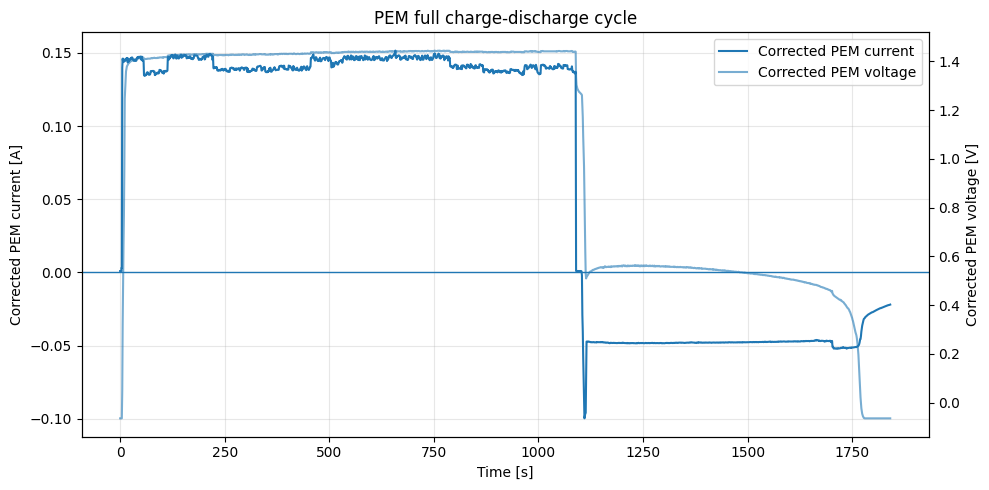

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    full_cycle["time_s"],
    full_cycle["pem_current_A"],
    label="Corrected PEM current",
)

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Corrected PEM current [A]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    full_cycle["time_s"],
    full_cycle["pem_voltage_V"],
    alpha=0.6,
    label="Corrected PEM voltage",
)
ax2.set_ylabel("Corrected PEM voltage [V]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("PEM full charge-discharge cycle")
plt.tight_layout()
plt.show()


## 2. Charge calibration from the full charge part

The active electrolysis region is selected as Scenario 3 with corrected PEM current above 0.05 A. The measured full hydrogen capacity after the charge is 15.6 mL.

In [ ]:
full_charge = full_cycle[
    (full_cycle["scenario"] == 3)
    & (full_cycle["pem_current_A"] > CHARGE_CURRENT_THRESHOLD_A)
].copy()

if full_charge.empty:
    raise ValueError("No active full-charge region found. Check scenario number or current threshold.")

full_charge["charge_time_s"] = full_charge["time_s"] - full_charge["time_s"].iloc[0]

full_charge_duration_s = float(full_charge["charge_time_s"].iloc[-1])

full_input_charge_C = trapezoid_integral(
    full_charge["pem_current_A"],
    full_charge["charge_time_s"],
)

full_input_energy_J = trapezoid_integral(
    full_charge["pem_charge_power_W"],
    full_charge["charge_time_s"],
)

HYDROGEN_PRODUCTION_ML_PER_INPUT_C = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_input_charge_C
)

HYDROGEN_PRODUCTION_ML_PER_INPUT_J = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_input_energy_J
)

HYDROGEN_CHARGE_RATE_ML_PER_S = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_charge_duration_s
)

HYDROGEN_CHARGE_RATE_ML_PER_MIN = (
    HYDROGEN_CHARGE_RATE_ML_PER_S * 60
)

HYDROGEN_COULOMB_EFFICIENCY = (
    HYDROGEN_PRODUCTION_ML_PER_INPUT_C / FARADAY_THEORETICAL_H2_ML_PER_C
)

charge_results = pd.DataFrame({
    "quantity": [
        "active charge duration",
        "integrated input charge",
        "integrated input energy",
        "measured full H2 capacity",
        "H2 production constant",
        "H2 energy constant",
        "average H2 charge rate",
        "average H2 charge rate",
        "Faradaic efficiency estimate",
    ],
    "value": [
        full_charge_duration_s,
        full_input_charge_C,
        full_input_energy_J,
        MEASURED_FULL_HYDROGEN_CAPACITY_ML,
        HYDROGEN_PRODUCTION_ML_PER_INPUT_C,
        HYDROGEN_PRODUCTION_ML_PER_INPUT_J,
        HYDROGEN_CHARGE_RATE_ML_PER_S,
        HYDROGEN_CHARGE_RATE_ML_PER_MIN,
        100 * HYDROGEN_COULOMB_EFFICIENCY,
    ],
    "unit": [
        "s", "C", "J", "mL", "mL/C", "mL/J", "mL/s", "mL/min", "%"
    ],
})

display(charge_results)

print(f"Final EMS charge constant: {HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.5f} mL/C")


,quantity,value,unit
0,active charge duration,1083.000000,s
1,integrated input charge,154.169893,C
2,integrated input energy,220.208540,J
3,measured full H2 capacity,15.600000,mL
4,H2 production constant,0.101187,mL/C
5,H2 energy constant,0.070842,mL/J
6,average H2 charge rate,0.014404,mL/s
7,average H2 charge rate,0.864266,mL/min
8,Faradaic efficiency estimate,81.358622,%


Final EMS charge constant: 0.10119 mL/C


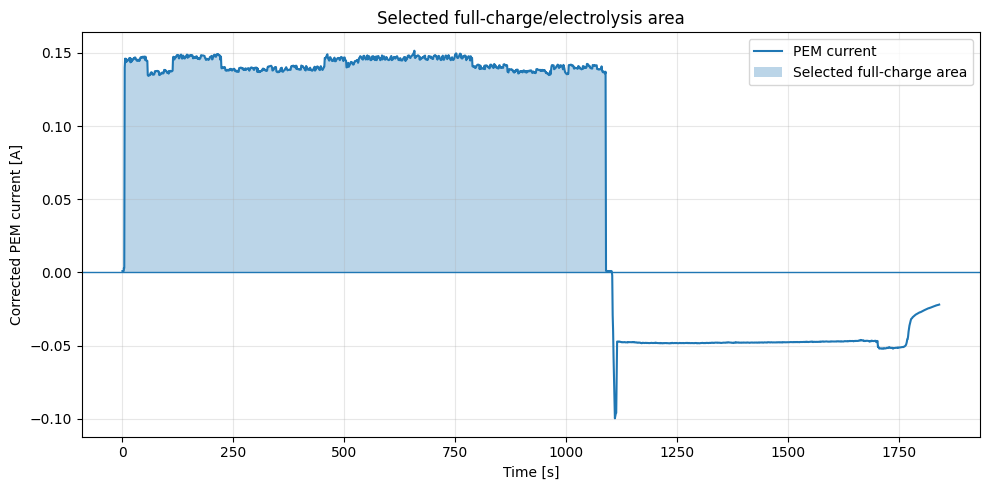

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    full_cycle["time_s"],
    full_cycle["pem_current_A"],
    label="PEM current",
    linewidth=1.5,
)

ax.fill_between(
    full_charge["time_s"],
    full_charge["pem_current_A"],
    alpha=0.3,
    label="Selected full-charge area",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Corrected PEM current [A]")
ax.set_title("Selected full-charge/electrolysis area")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


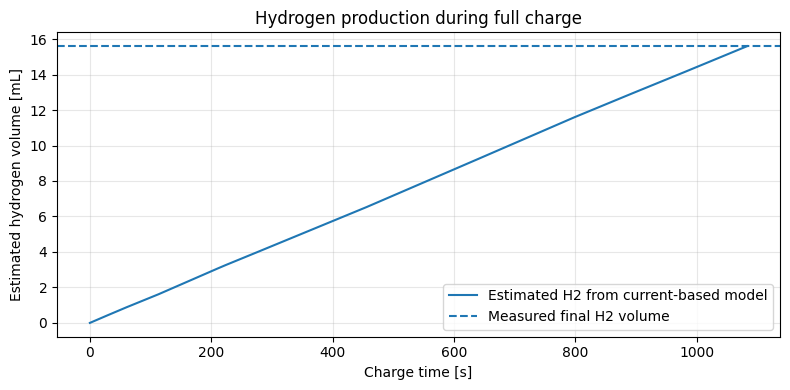

In [ ]:
charge_profile = full_charge.copy()

charge_profile["cumulative_charge_C"] = cumulative_trapezoid(
    charge_profile["pem_current_A"],
    charge_profile["charge_time_s"],
)

charge_profile["estimated_H2_mL"] = (
    charge_profile["cumulative_charge_C"] * HYDROGEN_PRODUCTION_ML_PER_INPUT_C
)

plt.figure(figsize=(8, 4))
plt.plot(
    charge_profile["charge_time_s"],
    charge_profile["estimated_H2_mL"],
    label="Estimated H2 from current-based model",
)

plt.axhline(
    MEASURED_FULL_HYDROGEN_CAPACITY_ML,
    linestyle="--",
    label="Measured final H2 volume",
)

plt.xlabel("Charge time [s]")
plt.ylabel("Estimated hydrogen volume [mL]")
plt.title("Hydrogen production during full charge")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Discharge calibration from the full discharge part

The active fuel-cell region is selected as Scenario 6 with corrected PEM current below -0.005 A and positive PEM voltage. The positive-voltage condition avoids including the final collapsed-voltage tail as useful fuel-cell output.

If the cylinder was not fully emptied during the test, update `MEASURED_REMAINING_HYDROGEN_AFTER_FULL_DISCHARGE_ML` in the first cell.

In [ ]:
full_discharge = full_cycle[
    (full_cycle["scenario"] == 6)
    & (full_cycle["pem_current_A"] < DISCHARGE_CURRENT_THRESHOLD_A)
    & (full_cycle["pem_voltage_V"] > DISCHARGE_MIN_USABLE_VOLTAGE_V)
].copy()

if full_discharge.empty:
    raise ValueError("No active full-discharge region found. Check scenario number, current threshold, or voltage threshold.")

full_discharge["discharge_time_s"] = full_discharge["time_s"] - full_discharge["time_s"].iloc[0]

full_discharge_duration_s = float(full_discharge["discharge_time_s"].iloc[-1])

full_output_charge_C = trapezoid_integral(
    full_discharge["pem_discharge_current_A"],
    full_discharge["discharge_time_s"],
)

full_output_energy_J = trapezoid_integral(
    full_discharge["pem_discharge_power_W"],
    full_discharge["discharge_time_s"],
)

HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / full_output_charge_C
)

HYDROGEN_DISCHARGE_ML_PER_OUTPUT_J = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / full_output_energy_J
)

HYDROGEN_DISCHARGE_RATE_ML_PER_S = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / full_discharge_duration_s
)

HYDROGEN_DISCHARGE_RATE_ML_PER_MIN = (
    HYDROGEN_DISCHARGE_RATE_ML_PER_S * 60
)

round_trip_efficiency = full_output_energy_J / full_input_energy_J

discharge_results = pd.DataFrame({
    "quantity": [
        "active discharge duration",
        "integrated output charge",
        "integrated output energy",
        "measured usable H2 discharge",
        "H2 discharge constant",
        "H2 discharge energy constant",
        "average H2 discharge rate",
        "average H2 discharge rate",
        "round-trip efficiency estimate",
    ],
    "value": [
        full_discharge_duration_s,
        full_output_charge_C,
        full_output_energy_J,
        MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
        HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C,
        HYDROGEN_DISCHARGE_ML_PER_OUTPUT_J,
        HYDROGEN_DISCHARGE_RATE_ML_PER_S,
        HYDROGEN_DISCHARGE_RATE_ML_PER_MIN,
        100 * round_trip_efficiency,
    ],
    "unit": [
        "s", "C", "J", "mL", "mL/C", "mL/J", "mL/s", "mL/min", "%"
    ],
})

display(discharge_results)

print(f"Final EMS discharge constant: {HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C:.5f} mL/C")


,quantity,value,unit
0,active discharge duration,665.000000,s
1,integrated output charge,32.262211,C
2,integrated output energy,16.867281,J
3,measured usable H2 discharge,15.600000,mL
4,H2 discharge constant,0.483538,mL/C
5,H2 discharge energy constant,0.924868,mL/J
6,average H2 discharge rate,0.023459,mL/s
7,average H2 discharge rate,1.407519,mL/min
8,round-trip efficiency estimate,7.659685,%


Final EMS discharge constant: 0.48354 mL/C


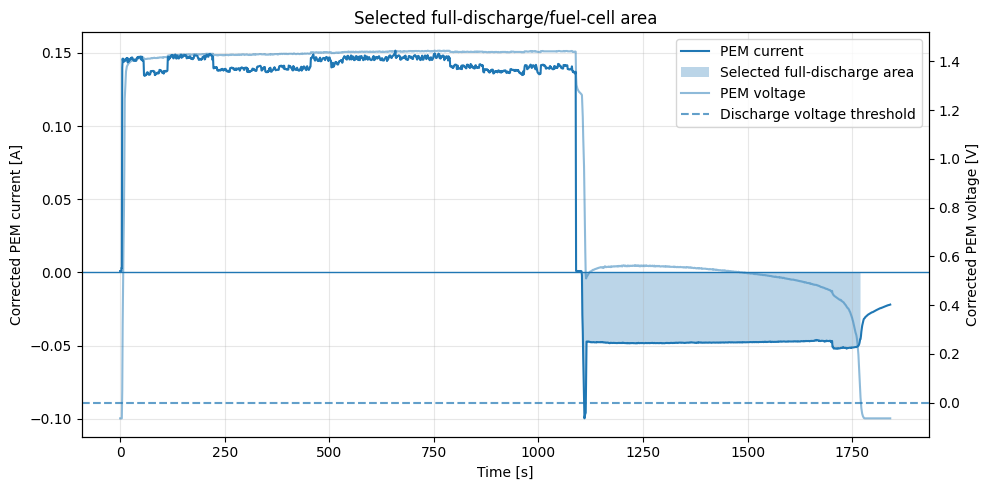

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    full_cycle["time_s"],
    full_cycle["pem_current_A"],
    label="PEM current",
    linewidth=1.5,
)

ax1.fill_between(
    full_discharge["time_s"],
    full_discharge["pem_current_A"],
    alpha=0.3,
    label="Selected full-discharge area",
)

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Corrected PEM current [A]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    full_cycle["time_s"],
    full_cycle["pem_voltage_V"],
    alpha=0.5,
    label="PEM voltage",
)
ax2.axhline(
    DISCHARGE_MIN_USABLE_VOLTAGE_V,
    linestyle="--",
    alpha=0.7,
    label="Discharge voltage threshold",
)
ax2.set_ylabel("Corrected PEM voltage [V]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Selected full-discharge/fuel-cell area")
plt.tight_layout()
plt.show()


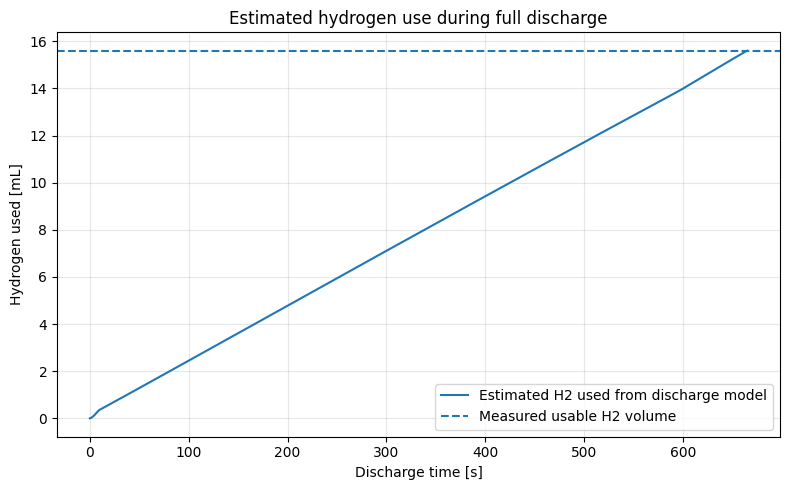

In [ ]:
discharge_profile = full_discharge.copy()

discharge_profile["cumulative_output_charge_C"] = cumulative_trapezoid(
    discharge_profile["pem_discharge_current_A"],
    discharge_profile["discharge_time_s"],
)

discharge_profile["estimated_H2_used_mL"] = (
    discharge_profile["cumulative_output_charge_C"] * HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C
)

plt.figure(figsize=(8, 5))
plt.plot(
    discharge_profile["discharge_time_s"],
    discharge_profile["estimated_H2_used_mL"],
    label="Estimated H2 used from discharge model",
)

plt.axhline(
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
    linestyle="--",
    label="Measured usable H2 volume",
)

plt.xlabel("Discharge time [s]")
plt.ylabel("Hydrogen used [mL]")
plt.title("Estimated hydrogen use during full discharge")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Optional short-test validation

This section validates the final current-based charge constant on the original short charge tests if the short-test CSV files and manual readings file are available in the project folder. If they are not available, the cell is skipped.

In [ ]:
def find_optional_project_root_with_data() -> Path | None:
    cwd = Path.cwd().resolve()
    for parent in [cwd, *cwd.parents]:
        if (parent / "data").exists():
            return parent
    return None


def parse_setpoints(file_name):
    """
    Example: discharge_040A_120s_r1.csv -> current = 0.40 A, duration = 120 s
    """
    parts = file_name.replace(".csv", "").split("_")
    current_A = int(parts[1].replace("A", "")) / 100
    duration_s = int(parts[2].replace("s", ""))
    return current_A, duration_s


def load_active_charge_part(file):
    """
    Load one short-test file and select only the active electrolysis section.
    """
    df = pd.read_csv(file)
    df = preprocess_pem_data(df)

    charge = df[
        (df["scenario"] == 3)
        & (df["pem_current_A"] > CHARGE_CURRENT_THRESHOLD_A)
    ].copy()

    if charge.empty:
        raise ValueError(f"No active charge region found in {file.name}")

    charge["charge_time_s"] = charge["time_s"] - charge["time_s"].iloc[0]
    return charge

PROJECT_ROOT = find_optional_project_root_with_data()

if PROJECT_ROOT is None:
    print("Skipped short-test validation because no project data folder was found.")
else:
    readings_file = PROJECT_ROOT / "data/PEM_test/volume_readings/readings.csv"
    pem_folder = PROJECT_ROOT / "data/PEM_test/charge_discharge"
    test_files = sorted(pem_folder.glob("discharge_*s_r1.csv"))

    if not readings_file.exists() or len(test_files) == 0:
        print("Skipped short-test validation because readings.csv or short-test CSV files were not found.")
        print(f"Expected readings file: {readings_file}")
        print(f"Expected short-test folder: {pem_folder}")
    else:
        volume_readings = pd.read_csv(readings_file)
        rows = []

        for file in test_files:
            current_setpoint_A, duration_setpoint_s = parse_setpoints(file.name)
            charge = load_active_charge_part(file)

            input_charge_C = trapezoid_integral(
                charge["pem_current_A"],
                charge["charge_time_s"],
            )

            volume_match = volume_readings[
                (volume_readings["current_A"] == current_setpoint_A)
                & (volume_readings["time_s"] == duration_setpoint_s)
            ]

            if volume_match.empty:
                continue

            measured_h2_mL = float(volume_match["volume_mL"].iloc[0])
            predicted_h2_mL = input_charge_C * HYDROGEN_PRODUCTION_ML_PER_INPUT_C

            rows.append({
                "file": file.name,
                "current_setpoint_A": current_setpoint_A,
                "duration_setpoint_s": duration_setpoint_s,
                "input_charge_C": input_charge_C,
                "measured_h2_mL": measured_h2_mL,
                "predicted_h2_current_model_mL": predicted_h2_mL,
                "error_mL": predicted_h2_mL - measured_h2_mL,
            })

        short_validation = pd.DataFrame(rows)

        if short_validation.empty:
            print("No matching short-test readings were found.")
        else:
            short_validation = short_validation.sort_values(
                ["current_setpoint_A", "duration_setpoint_s"]
            ).reset_index(drop=True)

            short_validation["error_percent"] = (
                100 * short_validation["error_mL"] / short_validation["measured_h2_mL"]
            )

            display(short_validation)

            mae_current = short_validation["error_mL"].abs().mean()
            rmse_current = np.sqrt(np.mean(short_validation["error_mL"] ** 2))

            print("Validation of final current-based model on short tests")
            print(f"Current-based model constant: {HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.5f} mL/C")
            print(f"Current-based MAE:  {mae_current:.3f} mL")
            print(f"Current-based RMSE: {rmse_current:.3f} mL")

            max_h2 = max(
                short_validation["measured_h2_mL"].max(),
                short_validation["predicted_h2_current_model_mL"].max(),
            )

            plt.figure(figsize=(7, 5))
            plt.scatter(
                short_validation["measured_h2_mL"],
                short_validation["predicted_h2_current_model_mL"],
                label="Current-based SoH model",
            )
            plt.plot(
                [0, max_h2],
                [0, max_h2],
                linestyle="--",
                color="black",
                label="Perfect prediction",
            )
            plt.title("Short-test validation of current-based H2 SoH model")
            plt.xlabel("Measured H2 volume [mL]")
            plt.ylabel("Predicted H2 volume [mL]")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()


Skipped short-test validation because no project data folder was found.


## 5. Final current-based EMS/SoH model

The final model updates the hydrogen estimate directly from the corrected PEM current. Positive current increases the hydrogen estimate during electrolysis, while negative current decreases it during fuel-cell operation.

In [ ]:
ems_parameters = pd.DataFrame({
    "parameter": [
        "H2_MAX_ML",
        "H2_MIN_USABLE_ML",
        "H2_USABLE_ML",
        "HYDROGEN_PRODUCTION_ML_PER_INPUT_C",
        "HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C",
        "HYDROGEN_CHARGE_RATE_ML_PER_MIN",
        "HYDROGEN_DISCHARGE_RATE_ML_PER_MIN",
        "ROUND_TRIP_EFFICIENCY",
        "CHARGE_CURRENT_THRESHOLD_A",
        "DISCHARGE_CURRENT_THRESHOLD_A",
        "DISCHARGE_MIN_USABLE_VOLTAGE_V",
    ],
    "value": [
        MEASURED_FULL_HYDROGEN_CAPACITY_ML,
        MEASURED_REMAINING_HYDROGEN_AFTER_FULL_DISCHARGE_ML,
        MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
        HYDROGEN_PRODUCTION_ML_PER_INPUT_C,
        HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C,
        HYDROGEN_CHARGE_RATE_ML_PER_MIN,
        HYDROGEN_DISCHARGE_RATE_ML_PER_MIN,
        round_trip_efficiency,
        CHARGE_CURRENT_THRESHOLD_A,
        DISCHARGE_CURRENT_THRESHOLD_A,
        DISCHARGE_MIN_USABLE_VOLTAGE_V,
    ],
    "unit": [
        "mL", "mL", "mL", "mL/C", "mL/C", "mL/min", "mL/min", "-", "A", "A", "V",
    ],
    "meaning": [
        "Measured full hydrogen capacity after full charge",
        "Measured remaining hydrogen after full discharge",
        "Usable hydrogen window for this full-cycle calibration",
        "Final charge constant from full charge test",
        "Final discharge constant from full discharge test",
        "Average charge rate during selected full charge interval",
        "Average discharge rate during selected full discharge interval",
        "Measured output energy divided by input energy for selected intervals",
        "Minimum current used to identify active electrolysis",
        "Maximum negative current threshold used to identify active discharge",
        "Minimum voltage used to exclude collapsed-voltage discharge tail",
    ],
})

display(ems_parameters)


,parameter,value,unit,meaning
0,H2_MAX_ML,15.600000,mL,Measured full hydrogen capacity after full charge
1,H2_MIN_USABLE_ML,0.000000,mL,Measured remaining hydrogen after full discharge
2,H2_USABLE_ML,15.600000,mL,Usable hydrogen window for this full-cycle cal...
3,HYDROGEN_PRODUCTION_ML_PER_INPUT_C,0.101187,mL/C,Final charge constant from full charge test
4,HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C,0.483538,mL/C,Final discharge constant from full discharge test
5,HYDROGEN_CHARGE_RATE_ML_PER_MIN,0.864266,mL/min,Average charge rate during selected full charg...
6,HYDROGEN_DISCHARGE_RATE_ML_PER_MIN,1.407519,mL/min,Average discharge rate during selected full di...
7,ROUND_TRIP_EFFICIENCY,0.076597,-,Measured output energy divided by input energy...
8,CHARGE_CURRENT_THRESHOLD_A,0.050000,A,Minimum current used to identify active electr...
9,DISCHARGE_CURRENT_THRESHOLD_A,-0.005000,A,Maximum negative current threshold used to ide...


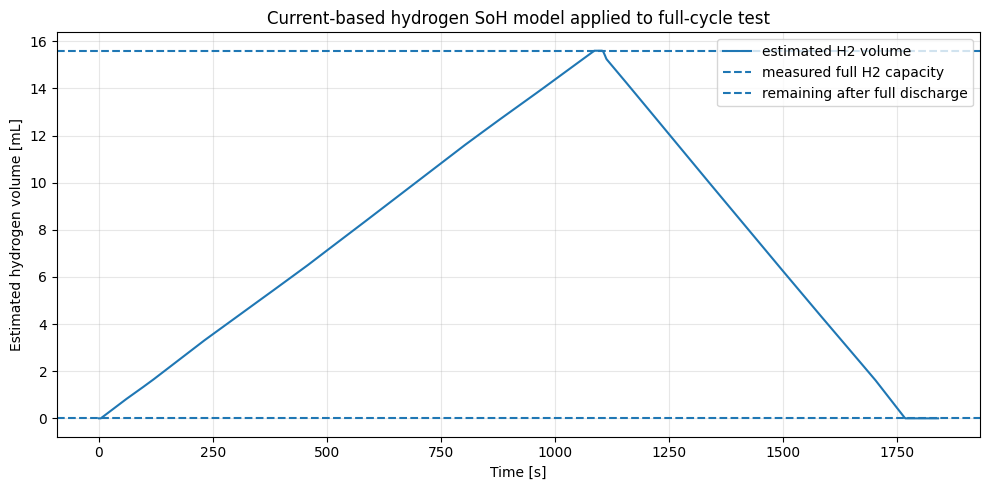

,timestamp,scenario,mode,time_s,pem_voltage_V,pem_current_A,estimated_h2_mL,usable_soh_percent
1742,2026-04-30 13:44:16,6,Scenario 6: PEM -> Load,1836.0,-0.064,-0.022414,0.0,0.0
1743,2026-04-30 13:44:18,6,Scenario 6: PEM -> Load,1838.0,-0.064,-0.022309,0.0,0.0
1744,2026-04-30 13:44:19,6,Scenario 6: PEM -> Load,1839.0,-0.064,-0.022204,0.0,0.0
1745,2026-04-30 13:44:20,6,Scenario 6: PEM -> Load,1840.0,-0.064,-0.022077,0.0,0.0
1746,2026-04-30 13:44:21,6,Scenario 6: PEM -> Load,1841.0,-0.064,-0.021993,0.0,0.0


In [ ]:
def estimate_h2_profile_from_current(
    df: pd.DataFrame,
    initial_h2_mL: float = 0.0,
    h2_min_mL: float = 0.0,
    h2_max_mL: float = MEASURED_FULL_HYDROGEN_CAPACITY_ML,
) -> pd.DataFrame:
    """
    Apply the final current-based H2 SoH model to a measured PEM current profile.
    """
    out = df.copy()
    out["dt_s"] = out["time_s"].diff().fillna(0)

    h2_values = []
    h2_mL = initial_h2_mL

    for _, row in out.iterrows():
        I = row["pem_current_A"]
        V = row["pem_voltage_V"]
        dt_s = row["dt_s"]

        if I > CHARGE_CURRENT_THRESHOLD_A:
            h2_mL += HYDROGEN_PRODUCTION_ML_PER_INPUT_C * I * dt_s

        elif I < DISCHARGE_CURRENT_THRESHOLD_A and V > DISCHARGE_MIN_USABLE_VOLTAGE_V:
            h2_mL -= HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C * abs(I) * dt_s

        h2_mL = min(max(h2_mL, h2_min_mL), h2_max_mL)
        h2_values.append(h2_mL)

    out["estimated_h2_mL"] = h2_values
    out["usable_soh"] = (
        (out["estimated_h2_mL"] - MEASURED_REMAINING_HYDROGEN_AFTER_FULL_DISCHARGE_ML)
        / MEASURED_USABLE_HYDROGEN_DISCHARGE_ML
    ).clip(0, 1)

    out["usable_soh_percent"] = 100 * out["usable_soh"]
    return out


soh_profile = estimate_h2_profile_from_current(
    full_cycle,
    initial_h2_mL=0.0,
    h2_min_mL=MEASURED_REMAINING_HYDROGEN_AFTER_FULL_DISCHARGE_ML,
    h2_max_mL=MEASURED_FULL_HYDROGEN_CAPACITY_ML,
)

plt.figure(figsize=(10, 5))
plt.plot(
    soh_profile["time_s"],
    soh_profile["estimated_h2_mL"],
    label="estimated H2 volume",
)

plt.axhline(MEASURED_FULL_HYDROGEN_CAPACITY_ML, linestyle="--", label="measured full H2 capacity")
plt.axhline(MEASURED_REMAINING_HYDROGEN_AFTER_FULL_DISCHARGE_ML, linestyle="--", label="remaining after full discharge")

plt.xlabel("Time [s]")
plt.ylabel("Estimated hydrogen volume [mL]")
plt.title("Current-based hydrogen SoH model applied to full-cycle test")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(
    soh_profile[
        ["timestamp", "scenario", "mode", "time_s", "pem_voltage_V", "pem_current_A", "estimated_h2_mL", "usable_soh_percent"]
    ].tail()
)


## Interpretation

The final current-based constants from this full-cycle test are the values in mL/C. These are the most suitable constants for the EMS because they can be updated directly from the measured PEM current.

The charge constant is based on the full electrolysis period and the observed final hydrogen volume of 15.6 mL. The discharge constant is based on the useful positive-voltage discharge region and the assumed usable hydrogen decrease from 15.6 mL to the observed remaining volume. If the observed remaining volume was not zero, update the value in the first cell and rerun the notebook.
